<a href="https://colab.research.google.com/github/AltagiAbdallah/Healthcare-Revenue-Recovery-Analysis-of-NHS-Data/blob/main/Healthcare_Revenue_Recovery_Analysis_of_NHS_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Data Ingestion & Setup**

In [3]:
import kagglehub
path = kagglehub.dataset_download("fungainicolechirombe/nhs-free-dataset-for-analysis")

100%|██████████| 8.38M/8.38M [00:00<00:00, 111MB/s]

Extracting files...


**2. Data Cleaning & Feature Engineering**

Parse the 'Month-Year' strings into datetime objects and sort the timeline to allow for chronological analysis.

In [4]:
import pandas as pd
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt

# 1. To find the CSV file inside the downloaded path
# We use os.path.join to look inside the folder 'path'
csv_files = glob.glob(os.path.join(path, '*.csv'))

if csv_files:
    # Load the first CSV found
    print(f"File found: {csv_files[0]}")
    df = pd.read_csv(csv_files[0])
    print("✅ Real NHS Data Loaded Successfully!")
else:
    print("❌ No CSV file found in the path.")

# 2. Inspect the Data Structure
print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())

print("\n--- FIRST 5 ROWS ---")
print(df.head())

# 3. Check for Missing Values
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

File found: /root/.cache/kagglehub/datasets/fungainicolechirombe/nhs-free-dataset-for-analysis/versions/2/Consultation.csv
✅ Real NHS Data Loaded Successfully!

--- COLUMN NAMES ---
['CALENDAR_MONTH_END_DATE', 'APC_Finished_Consultant', 'APC_FCEs_with_a_procedure', 'APC_Percent_FCEs_with_procedure', 'APC_Ordinary_Episodes', 'APC_Day_Case_Episodes', 'APC_Day_Case_Episodes_with_proc', 'APC_Percent_Day_Cases_with_proc', 'APC_Finished_Admission_Episodes', 'APC_Emergency', 'Outpatient_Total_Appointments', 'Outpatient_Attended_Appointments', 'Outpatient_Percent_Attended', 'Outpatient_DNA_Appointment', 'Outpatient_Percent_DNA', 'Outpatient_Follow_Up_Attendance', 'Outpatient_Attendance_Type_1', 'Outpatient_Attendance_Type_2']

--- FIRST 5 ROWS ---
  CALENDAR_MONTH_END_DATE  APC_Finished_Consultant  APC_FCEs_with_a_procedure  \
0                  Mar-25                  1922153                    1120099   
1                  Feb-25                  1770033                    1063949   
2      

**3. Financial Modeling (The "Waste" Metric)**

Quantify the operational loss. We apply an average cost-per-appointment (£160) to the 'Did Not Attend' (DNA) volume to estimate monthly revenue leakage.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Convert Date Column
# The format 'Mar-25' means Month-Year. We convert it to a datetime object.
try:
    df['Date'] = pd.to_datetime(df['CALENDAR_MONTH_END_DATE'], format='%b-%y')
except:
    # Fallback if format is different (sometimes it's '%b-%Y')
    df['Date'] = pd.to_datetime(df['CALENDAR_MONTH_END_DATE'], infer_datetime_format=True)

# Sort by date to make charts look right
df = df.sort_values('Date')

# 2. Inspect the Cleaned Data
print("--- TIME SERIES RANGE ---")
print(f"Start: {df['Date'].min()}")
print(f"End:   {df['Date'].max()}")

print("\n--- SAMPLE DATA ---")
print(df[['Date', 'APC_Emergency', 'Outpatient_DNA_Appointment']].head())

--- TIME SERIES RANGE ---
Start: 2007-04-01 00:00:00
End:   2025-03-01 00:00:00

--- SAMPLE DATA ---
          Date  APC_Emergency  Outpatient_DNA_Appointment
215 2007-04-01         387887                      427315
214 2007-05-01         407946                      469044
213 2007-06-01         390411                      465544
212 2007-07-01         397923                      476312
211 2007-08-01         391334                      459439


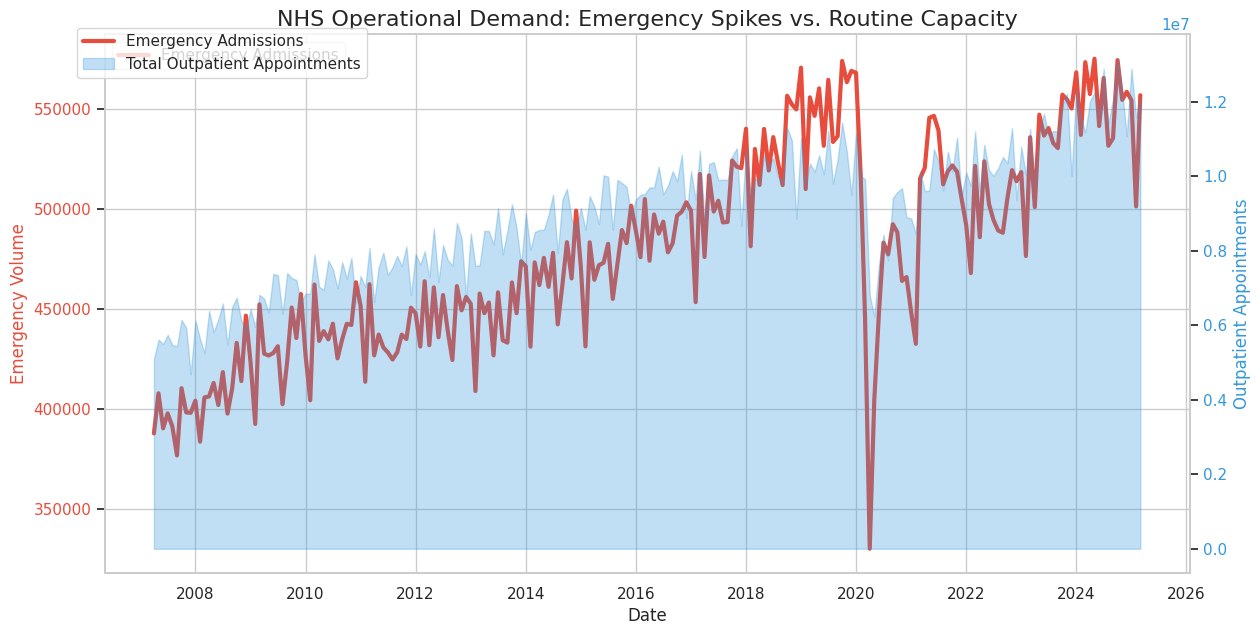

In [6]:
# Create a Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot 1: Emergency Admissions (Red Line - Critical Demand)
sns.lineplot(data=df, x='Date', y='APC_Emergency', ax=ax1, color='#e74c3c', label='Emergency Admissions', linewidth=3)
ax1.set_ylabel('Emergency Volume', color='#e74c3c', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#e74c3c')

# Create a twin axis for Outpatient data (Blue Area - Routine Demand)
ax2 = ax1.twinx()
ax2.fill_between(df['Date'], df['Outpatient_Total_Appointments'], color='#3498db', alpha=0.3, label='Total Outpatient Appointments')
ax2.set_ylabel('Outpatient Appointments', color='#3498db', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#3498db')

plt.title('NHS Operational Demand: Emergency Spikes vs. Routine Capacity', fontsize=16)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid(False) # Turn off grid for second axis for clarity
plt.show()

**4. Visualizing Financial Impact**

Generate a Horizontal Loss Chart to immediately highlight the months with the highest financial drain. This format is chosen for readability of dates and financial figures.

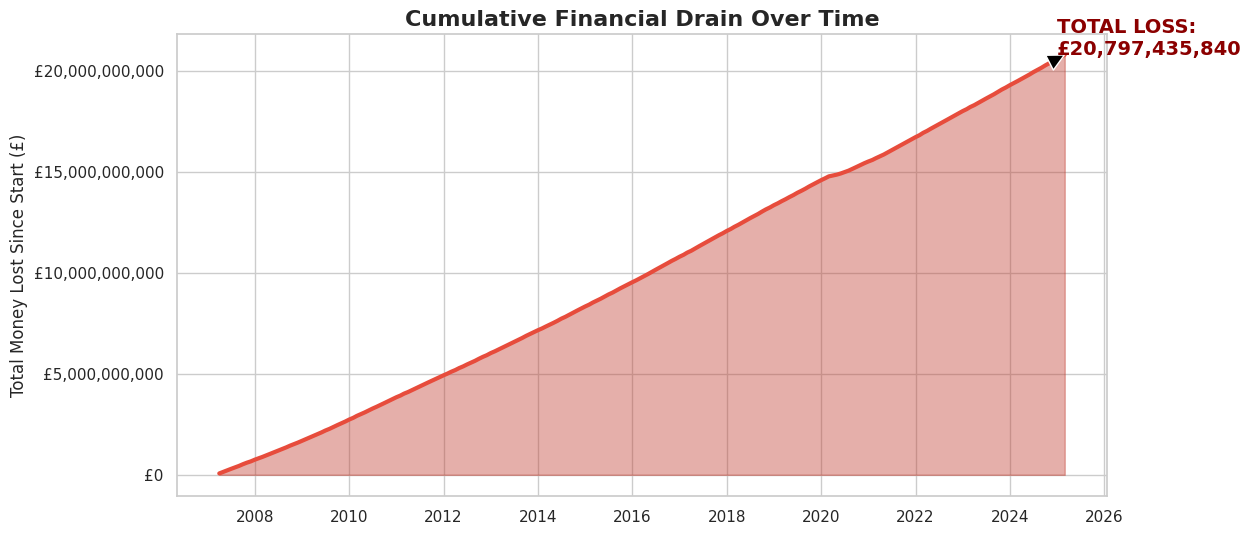

In [14]:
# 1. Calculate Cumulative Loss (The "Running Total")
df['Cumulative_Waste'] = df['Money_Lost'].cumsum()

# 2. Create the "Mountain" Area Chart
plt.figure(figsize=(12, 6))

# Fill the area under the line
plt.fill_between(df['Date'], df['Cumulative_Waste'], color='#c0392b', alpha=0.4)
# Draw the line on top
sns.lineplot(data=df, x='Date', y='Cumulative_Waste', color='#e74c3c', linewidth=3)

# 3. Add Titles
plt.title('Cumulative Financial Drain Over Time', fontsize=16, weight='bold')
plt.ylabel('Total Money Lost Since Start (£)')
plt.xlabel('')

# 4. Format Money Axis
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

# 5. Add a "Final Total" Annotation
final_total = df['Cumulative_Waste'].max()
final_date = df['Date'].max()
plt.annotate(f'TOTAL LOSS:\n£{final_total:,.0f}',
             xy=(final_date, final_total),
             xytext=(final_date - pd.Timedelta(days=60), final_total),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=14, fontweight='bold', color='darkred')

plt.show()

**5. Executive Summary**

In [8]:
# Calculate Annual Impact
total_missed_year = df['Outpatient_DNA_Appointment'].sum()
# Assumption: An appointment costs approx £120 (avg NHS cost)
est_cost_waste = total_missed_year * 120

print("--- EXECUTIVE SUMMARY ---")
print(f"Total Missed Appointments (Dataset Period): {total_missed_year:,.0f}")
print(f"Estimated Financial Loss (@ £120/appt): £{est_cost_waste:,.0f}")
print("\nRECOMMENDATION:")
print("1. Implement SMS reminders to reduce DNA rate.")
print("2. Overbook clinics by 5% to compensate for the known attrition rate.")

--- EXECUTIVE SUMMARY ---
Total Missed Appointments (Dataset Period): 129,983,974
Estimated Financial Loss (@ £120/appt): £15,598,076,880

RECOMMENDATION:
1. Implement SMS reminders to reduce DNA rate.
2. Overbook clinics by 5% to compensate for the known attrition rate.
